1. Import  Libraries

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [67]:
data = pd.read_csv("hotel_bookings.csv")

#first 5 rows Show
data.head()

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


3. Basic Understanding

In [68]:
# rows aur columns
data.shape

(119390, 33)

In [69]:
# columns check
data.columns

Index(['index', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [70]:
# data types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           119390 non-null  int64  
 1   hotel                           119390 non-null  str    
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  str    
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies                     

In [71]:
# statistical summary
data.describe()

,index,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,...,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,59694.500000,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,...,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,34465.068657,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,...,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,29847.250000,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,59694.500000,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,89541.750000,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,119389.000000,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,...,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


4. Data Cleaning

In [72]:
# missing values check
data.isnull().sum()


index                                  0
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent           

In [73]:
# missing values fill 
data['children'] = data['children'].fillna(0)
data['country'] = data['country'].fillna('Unknown')
data['agent'] = data['agent'].fillna(0)
data['company'] = data['company'].fillna(0)

In [74]:
# duplicate values remove
data.drop_duplicates(inplace=True)

5. Feature Engineering

In [75]:
# total guests
data['total_guests'] = data['adults'] + data['children'] + data['babies']

In [76]:
# total nights calculate
data['total_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']

6. Exploratory Data Analysis (EDA)

In [77]:
# total bookings
len(data)

119390

In [78]:
# cancellation count
data['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [79]:
# hotel types
data['hotel'].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [80]:
# average lead time
data['lead_time'].mean()

np.float64(104.01141636652986)

In [81]:
# month wise bookings
data['arrival_date_month'].value_counts()

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

In [82]:
# top countries
data['country'].value_counts().head()

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
Name: count, dtype: int64

In [83]:
# cancellation rate
(data['is_canceled'].sum()/len(data))*100


np.float64(37.041628277075134)

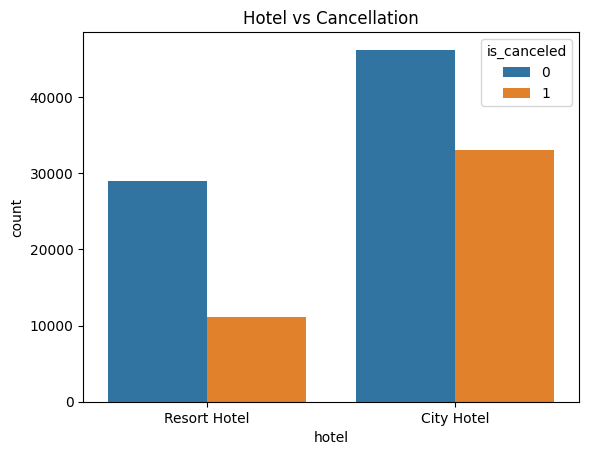

In [84]:
sns.countplot(x='hotel', hue='is_canceled', data=data)
plt.title("Hotel vs Cancellation")
plt.show()

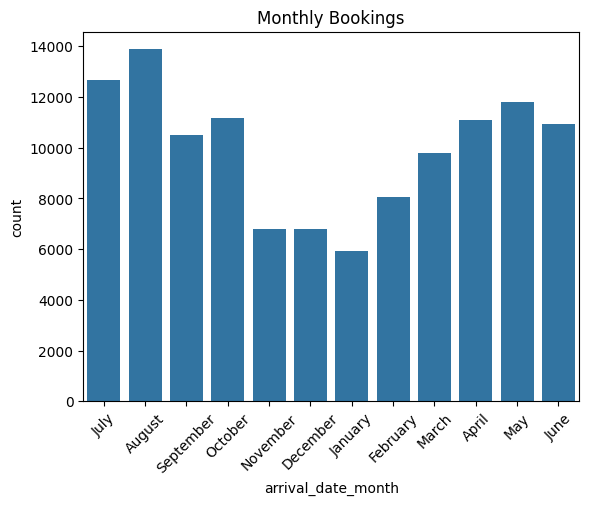

In [85]:
# month trend
sns.countplot(x='arrival_date_month', data=data)
plt.xticks(rotation=45)
plt.title("Monthly Bookings")
plt.show()

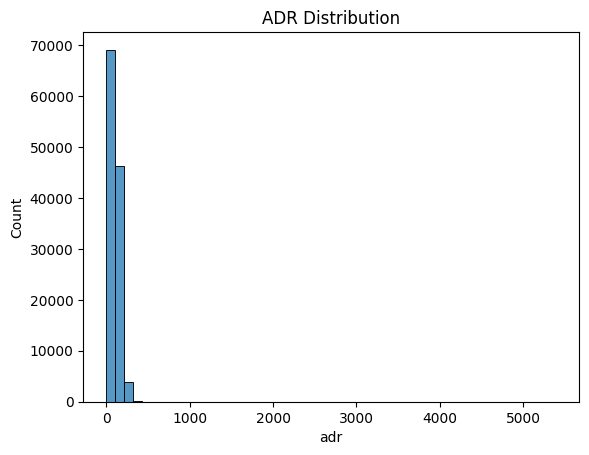

In [86]:
# adr distribution
sns.histplot(data['adr'], bins=50)
plt.title("ADR Distribution")
plt.show()

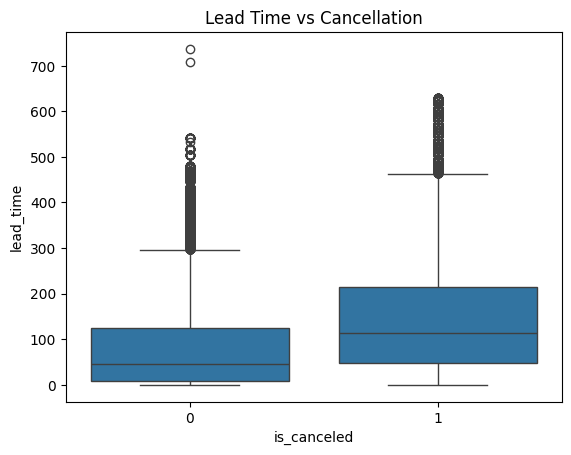

In [87]:
# lead time vs cancellation
sns.boxplot(x='is_canceled', y='lead_time', data=data)
plt.title("Lead Time vs Cancellation")
plt.show()

AVD analysis

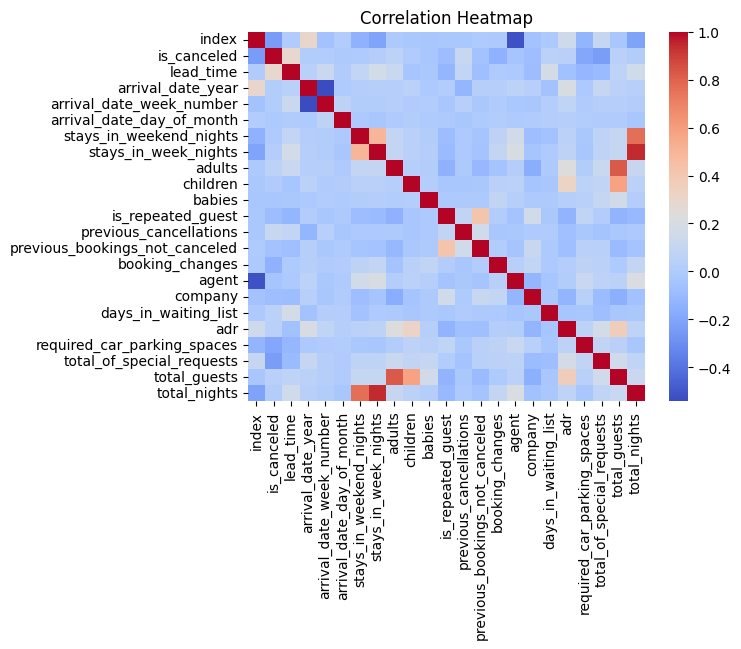

In [88]:
# correlation heatmap
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [89]:
# room type vs adr
data.groupby('reserved_room_type')['adr'].mean()

reserved_room_type
A     90.796658
B     90.360447
C    160.216792
D    120.682882
E    124.540179
F    167.689651
G    175.996027
H    188.223111
L    124.666667
P      0.000000
Name: adr, dtype: float64

In [90]:
# deposit type vs cancellation
data.groupby('deposit_type')['is_canceled'].mean()

deposit_type
No Deposit    0.283770
Non Refund    0.993624
Refundable    0.222222
Name: is_canceled, dtype: float64

In [91]:
# special requests vs cancellation
data.groupby('total_of_special_requests')['is_canceled'].mean()

total_of_special_requests
0    0.477204
1    0.220249
2    0.220989
3    0.178614
4    0.105882
5    0.050000
Name: is_canceled, dtype: float64

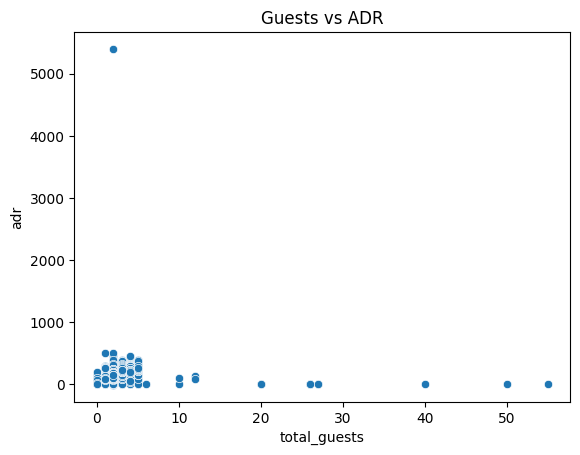

In [92]:
# total guests vs adr
sns.scatterplot(x='total_guests', y='adr', data=data)
plt.title("Guests vs ADR")
plt.show()